# 02 · Scenarios and uncertainty

A *scenario* in peteksim is not a new API — it is a **derived spec** re-applied to
the same geometry. Because specs compare and derive by value, N specs give N
deterministic models. This notebook derives two scenarios, adds **structural
uncertainty**, compares P-curves, and round-trips a whole scenario through a dict.

All synthetic (`ps.synth_asset`); nothing confidential.

In [1]:
import tempfile
import matplotlib
import matplotlib.pyplot as plt
import peteksim as ps

print("peteksim", ps.version())

peteksim 0.1.1


## Setup — a base model

We build a base model once and hold onto the specs so we can derive from them.

In [2]:
man  = ps.synth_asset(tempfile.mkdtemp(prefix="nb2-asset-"), seed=20260704, n_wells=8)
proj = ps.Project.load(man["root"],
                       settings=ps.LoadSettings(crs=man["crs"], aliases=man["aliases"]))

hz = ps.Horizons(
    *[ps.hz(h) for h in man["horizons"]],
    zones=man["zones"], ties=ps.TieSettings(method="convergent"),
    gridding=ps.Gridding(collapse=True),
)
lay   = ps.Layering(nk=2)
con   = ps.Contacts({z["zone"]: dict(z["contacts"])
                     for z in man["zonation"] if z["contacts"]})
props = ps.Props(
    ps.Prop("PORO", net_only=True,
            propagate=ps.Propagate(variogram=ps.variogram("spherical", 1500.0), seed=11)),
    ps.Prop("NTG",
            propagate=ps.Propagate(variogram=ps.variogram("spherical", 1500.0), seed=12)),
)

geom = proj.grid_geometry(cell=(50.0, 50.0), orient=0.0)
grid = geom.build(hz, layering=lay, collapse_negative=True, min_thickness_m=0.0)
base = grid.model(props, con, fluid="oil", fvf=1.30, gas_fvf=0.005, wells=proj.wells())

base_total = base.in_place_by_zone()["total"]["stoiip_msm3"]
print(f"base field STOIIP = {base_total:.4f} MSm3")

base field STOIIP = 0.1995 MSm3


## Scenario A — a deeper oil-water contact (`con.replace`)

`Contacts.replace` returns a **new** spec with Z4's fluid-contact deepened by 30 m.
The original spec is untouched; the geometry is reused. A deeper FWL means a taller
oil column, so more in-place oil.

In [3]:
deeper  = con.replace("Z4", goc=man["contacts"]["goc_z4"],
                      fwl=man["contacts"]["fwl_z4"] + 30.0)
model_a = grid.model(props, deeper, fluid="oil", fvf=1.30, gas_fvf=0.005)

total_a = model_a.in_place_by_zone()["total"]["stoiip_msm3"]
print(f"base            STOIIP = {base_total:.4f} MSm3")
print(f"deeper-FWL (A)  STOIIP = {total_a:.4f} MSm3   (+{total_a - base_total:.4f})")
assert con.for_zone("Z4")["fwl"] != deeper.for_zone("Z4")["fwl"]  # original intact

base            STOIIP = 0.1995 MSm3
deeper-FWL (A)  STOIIP = 4.5367 MSm3   (+4.3373)


## Scenario B — drop the deepest zone (`hz.replace`)

`Horizons.replace` derives a spec with the deepest zone **and** its base horizon
removed (the engine keeps `horizons = zones + 1`). Fewer zones means less gross
rock, hence less GRV.

In [4]:
hz_drop = hz.replace(rows=hz.rows[:-1], zones=hz.zones[:-1])
grid_b  = geom.build(hz_drop, layering=lay, collapse_negative=True, min_thickness_m=0.0)
model_b = grid_b.model(props, con, fluid="oil", fvf=1.30, gas_fvf=0.005)

zones_full = [r["zone"] for r in base.in_place_by_zone()["zones"]]
zones_drop = [r["zone"] for r in model_b.in_place_by_zone()["zones"]]
grv_full = base.in_place_by_zone()["total"]["grv_mcm"]
grv_drop = model_b.in_place_by_zone()["total"]["grv_mcm"]
print("zones full :", zones_full)
print("zones drop :", zones_drop)
print(f"GRV  full = {grv_full:.1f} mcm   ->   drop = {grv_drop:.1f} mcm")
assert len(zones_drop) == len(zones_full) - 1 and grv_drop < grv_full

zones full : ['Z0', 'Z1', 'Z2', 'Z3', 'Z4', 'Z5']
zones drop : ['Z0', 'Z1', 'Z2', 'Z3', 'Z4']
GRV  full = 694.7 mcm   ->   drop = 585.6 mcm


### Totals side by side

In [5]:
rows = [("base",            base_total, grv_full),
        ("A: deeper FWL",   total_a,    grv_full),
        ("B: zone dropped", model_b.in_place_by_zone()["total"]["stoiip_msm3"], grv_drop)]
print(f"{'scenario':18s}{'STOIIP_MSm3':>14s}{'GRV_mcm':>12s}")
for name, st, grv in rows:
    print(f"{name:18s}{st:14.4f}{grv:12.1f}")

scenario             STOIIP_MSm3     GRV_mcm
base                      0.1995       694.7
A: deeper FWL             4.5367       694.7
B: zone dropped           0.1995       585.6


## Structural uncertainty — a top-depth field

Structural uncertainty is opt-in on the horizon spec: `ps.hz(name, sd=, vgm=)`.
On the **top** row it plants a correlated top-depth field; on deeper rows,
isochore fields. Applied to a **zoned** model it perturbs every Monte Carlo draw
and **widens** the in-place spread. (On a non-zoned model it raises
`ps.NotYetSupported` — loud, never silent.)

We build a **control** (no field) and a **structural** case (12 m top-depth +
zone-0 isochore field), then run the same MC on each.

In [6]:
ties = ps.TieSettings(method="convergent")
grd  = ps.Gridding(collapse=True)

def build_model(sd):
    if sd > 0:
        rows  = [ps.hz(man["horizons"][0], sd=sd, vgm=("spherical", 2500.0)),
                 ps.hz(man["horizons"][1], sd=sd, vgm=("spherical", 2500.0))]
        rows += [ps.hz(h) for h in man["horizons"][2:]]
    else:
        rows  = [ps.hz(h) for h in man["horizons"]]
    hzz = ps.Horizons(*rows, zones=man["zones"], ties=ties, gridding=grd)
    g   = geom.build(hzz, layering=lay, collapse_negative=True, min_thickness_m=0.0)
    return g.model(props, con, fluid="oil", fvf=1.30, gas_fvf=0.005)

control    = build_model(0.0)
structural = build_model(12.0)

mc_ctrl = control.zoned_uncertainty(ps.Mc(porosity=0.01, contacts=4.0, n=256, seed=42))
mc_stru = structural.zoned_uncertainty(ps.Mc(porosity=0.01, contacts=4.0, n=256, seed=42))

def band(mc):
    t = mc.total["stoiip"]
    return t["p90_msm3"], t["p50_msm3"], t["p10_msm3"]

print(f"{'case':12s}{'P90':>9s}{'P50':>9s}{'P10':>9s}{'P10-P90':>10s}  MSm3")
for name, mc in [("control", mc_ctrl), ("structural", mc_stru)]:
    p90, p50, p10 = band(mc)
    print(f"{name:12s}{p90:9.4f}{p50:9.4f}{p10:9.4f}{p10 - p90:10.4f}")

case              P90      P50      P10   P10-P90  MSm3
control        0.0469   0.2344   0.6929    0.6460
structural     0.0000   0.7905   2.8087    2.8087


### The widened spread, plotted

Two histograms of the field STOIIP sample vectors: the structural case is visibly
broader — the top-depth field feeds extra variance into every draw.

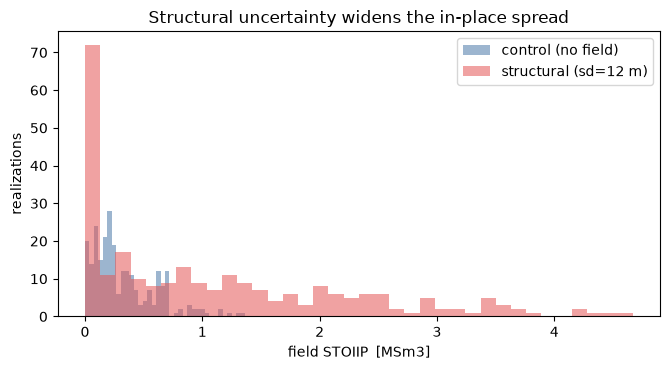

In [7]:
ctrl_s = [x / 1e6 for x in mc_ctrl.total["stoiip"]["samples"]]
stru_s = [x / 1e6 for x in mc_stru.total["stoiip"]["samples"]]

fig, ax = plt.subplots(figsize=(6.8, 3.8))
bins = 36
ax.hist(ctrl_s, bins=bins, color="#4C78A8", alpha=0.55, label="control (no field)")
ax.hist(stru_s, bins=bins, color="#E45756", alpha=0.55, label="structural (sd=12 m)")
ax.set_xlabel("field STOIIP  [MSm3]")
ax.set_ylabel("realizations")
ax.set_title("Structural uncertainty widens the in-place spread")
ax.legend()
fig.tight_layout()
plt.show()

## P-curve comparison

The exceedance (reverse-CDF) curve makes the P90/P50/P10 read directly: a flatter
curve is a wider distribution. The structural case sits wider than the control.

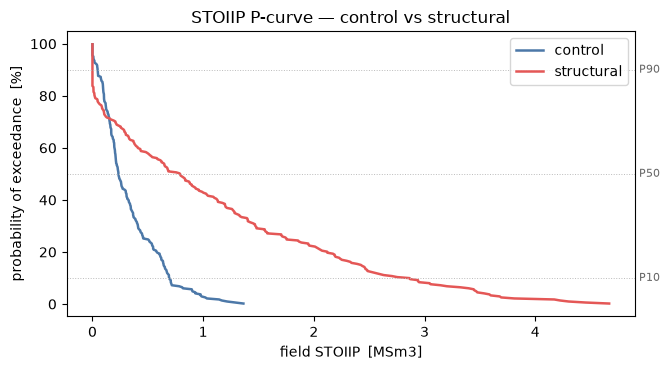

In [8]:
def exceedance(samples_msm3):
    xs = sorted(samples_msm3)
    n = len(xs)
    # probability of exceeding each value (reservoir convention)
    ys = [100.0 * (1.0 - (i + 0.5) / n) for i in range(n)]
    return xs, ys

fig, ax = plt.subplots(figsize=(6.8, 3.8))
for name, s, col in [("control", ctrl_s, "#4C78A8"),
                     ("structural", stru_s, "#E45756")]:
    xs, ys = exceedance(s)
    ax.plot(xs, ys, color=col, linewidth=1.8, label=name)
for pct in (90, 50, 10):
    ax.axhline(pct, color="#bbb", linewidth=0.7, linestyle=":")
    ax.text(ax.get_xlim()[1], pct, f" P{pct}", va="center", fontsize=8, color="#666")
ax.set_xlabel("field STOIIP  [MSm3]")
ax.set_ylabel("probability of exceedance  [%]")
ax.set_title("STOIIP P-curve — control vs structural")
ax.legend()
fig.tight_layout()
plt.show()

## A scenario is a savable file

`ps.AssetSpec` bundles a whole scenario — load settings, horizons, layering,
contacts, props — into one durable value that round-trips through
`to_dict()` / `ps.spec_from_dict(...)`. So a scenario is something you can version,
diff, and re-run bit-for-bit.

In [9]:
asset = ps.AssetSpec(
    name="deeper-fwl-scenario",
    load=ps.LoadSettings(crs=man["crs"]),
    horizons=hz, layering=lay, contacts=deeper, props=props,
)
blob = asset.to_dict()
restored = ps.spec_from_dict(blob)

print("to_dict keys :", sorted(blob.keys()))
print("round-trips  :", restored == asset)
assert restored == asset

to_dict keys : ['contacts', 'gridding', 'horizons', 'layering', 'load', 'mc', 'name', 'props', 'run', 'spec', 'subzones', 'ties', 'view']
round-trips  : True


## Recap

`con.replace(...)` and `hz.replace(...)` derive scenario specs from a base without
mutating it; each re-applies to the same geometry for a deterministic model.
`ps.hz(sd=, vgm=)` adds a structural-uncertainty field that widens the zoned-MC
spread (loud `NotYetSupported` on a flat model). `ps.AssetSpec` makes a whole
scenario a durable, round-trippable file — the foundation for versioned appraisal
cases.